II.Phân tích missing, quyết định strategy, demo encoding — viết giải thích vào notebook

1. Xem tổng quan các cột

In [1]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import os



#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv
    Args:
        dataset_path (str): đường dẫn file csv
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None

    try:
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None


#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())
print("- Các thông tin thống kê categorical:")
display(df.describe(include='object'))

Đã tải dữ liệu thành công!
Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.
- Các thông tin cơ bản:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
- Các thông tin thốn

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


C:\Users\ngoot\AppData\Local\Temp\ipykernel_18516\1168010254.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [2]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [3]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())
print("- Các thông tin thống kê categorical:")
display(df.describe(include='object'))

- Các thông tin thống kê numerical:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


C:\Users\ngoot\AppData\Local\Temp\ipykernel_18516\355905578.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [5]:
# hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
#ten các cột
df.columns.tolist()

['id',
 'age',
 'sex',
 'dataset',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [7]:
###1.Thống kê missing values
missing_summary = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

            column  missing_count  missing_percent
ca              ca            611        66.413043
thal          thal            486        52.826087
slope        slope            309        33.586957
fbs            fbs             90         9.782609
oldpeak    oldpeak             62         6.739130
trestbps  trestbps             59         6.413043
exang        exang             55         5.978261
thalch      thalch             55         5.978261
chol          chol             30         3.260870
restecg    restecg              2         0.217391
cp              cp              0         0.000000
dataset    dataset              0         0.000000
id              id              0         0.000000
age            age              0         0.000000
sex            sex              0         0.000000
num            num              0         0.000000


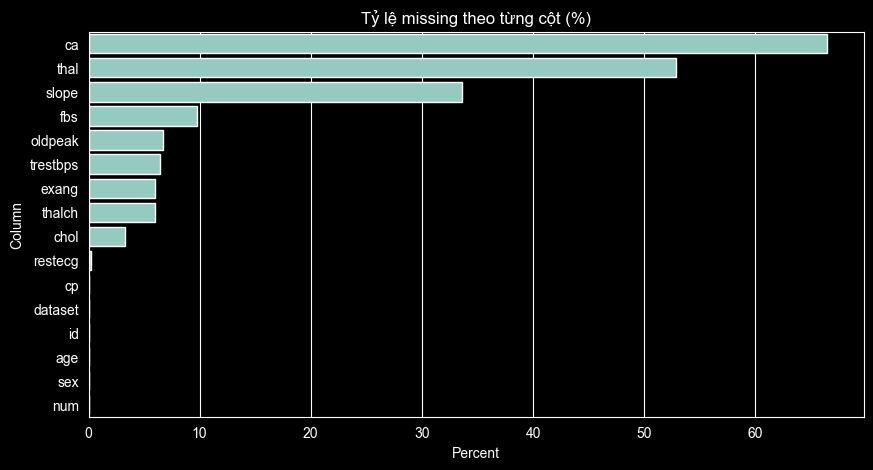

In [8]:
###2. Visualize missing
###a. Bar chart tỷ lệ missing
plt.figure(figsize=(10,5))
sns.barplot(x='missing_percent', y='column', data=missing_summary)
plt.title('Tỷ lệ missing theo từng cột (%)')
plt.xlabel('Percent')
plt.ylabel('Column')
plt.show()

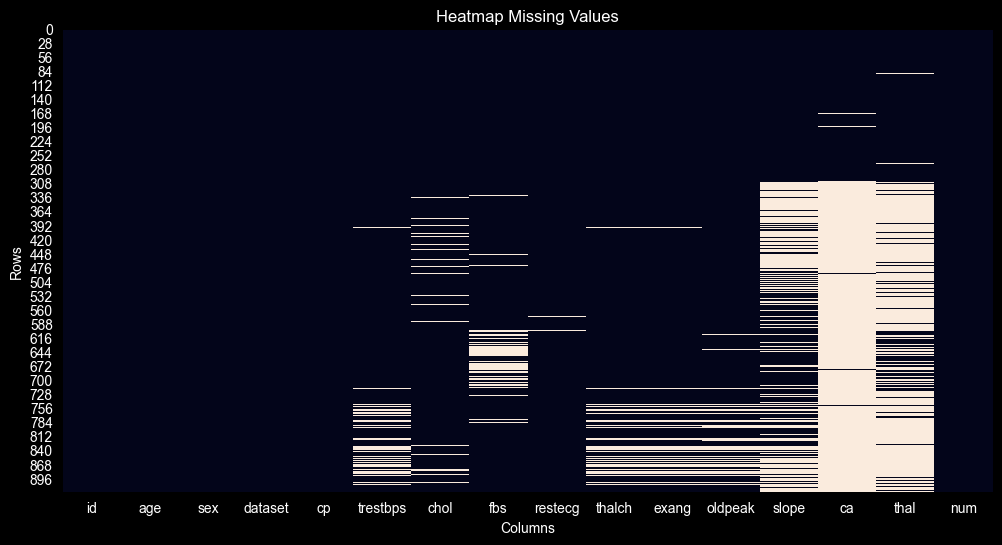

In [9]:
###b. Heatmap missing pattern
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Heatmap Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [10]:
###3. Kiểm tra nhanh các trường hợp quan trọng
# tổng số missing toàn dataset
total_missing = df.isnull().sum().sum()
print("Tổng số giá trị thiếu:", total_missing)

# cột nào > 50% missing
high_missing_cols = missing_summary[missing_summary['missing_percent'] > 50]
print("Cột có >50% missing:\n", high_missing_cols)

Tổng số giá trị thiếu: 1759
Cột có >50% missing:
      column  missing_count  missing_percent
ca       ca            611        66.413043
thal   thal            486        52.826087


5.Nhận Xét
- Dataset hầu như không có missing values đáng kể / hoặc có một số cột bị thiếu nhẹ.
- Không thấy pattern missing rõ ràng giữa các dòng.
- Không có cột nào vượt quá 50% missing nên chưa cần loại bỏ.
- Tuy nhiên khi deploy thực tế, dữ liệu bệnh nhân mới có thể thiếu các cột như ca hoặc thal, cần chuẩn bị pipeline xử lý.

2. Quyết định chiến lược

Chọn Strategy cho từng cột
- mean: age, trestbps, thalach
- median: chol, oldpeak
- mode: sex, cp, fbs, restecg, exang, slope, thal, ca

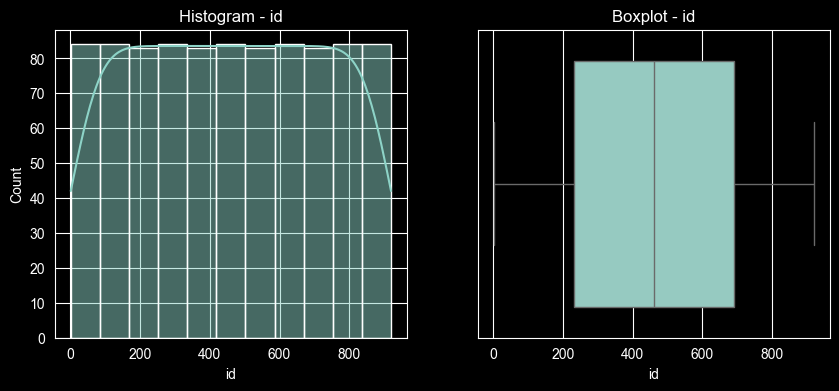

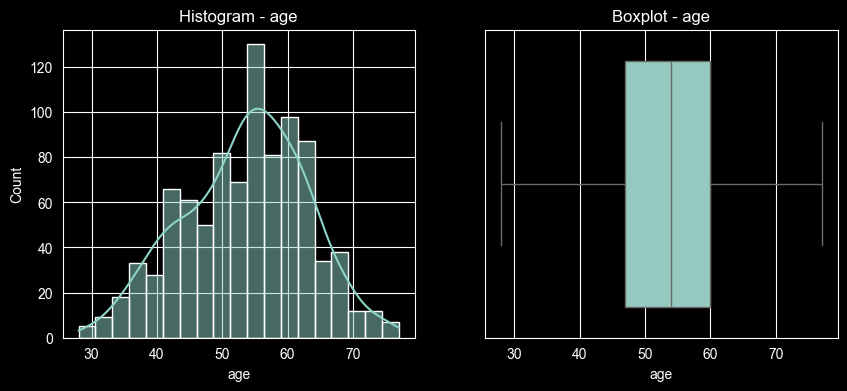

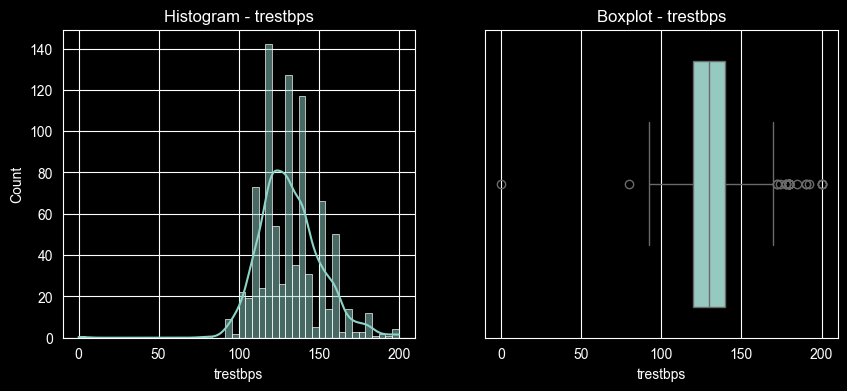

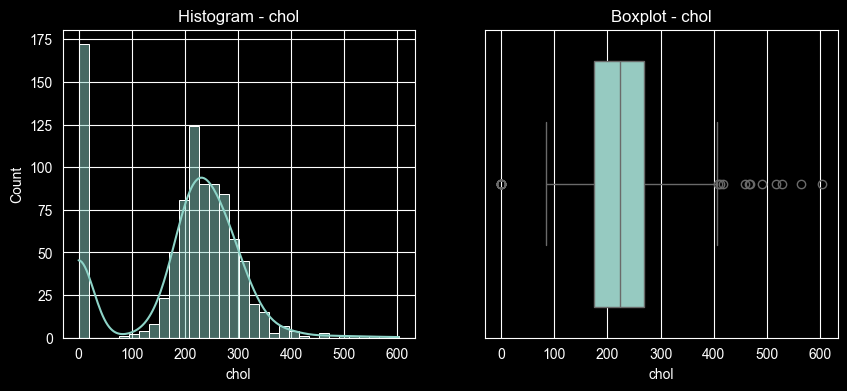

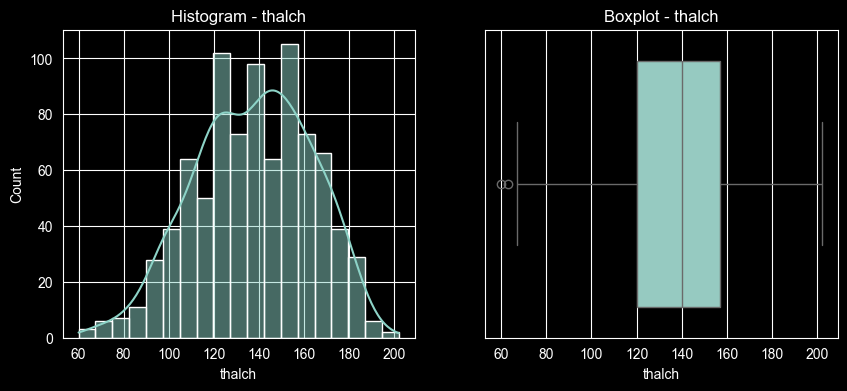

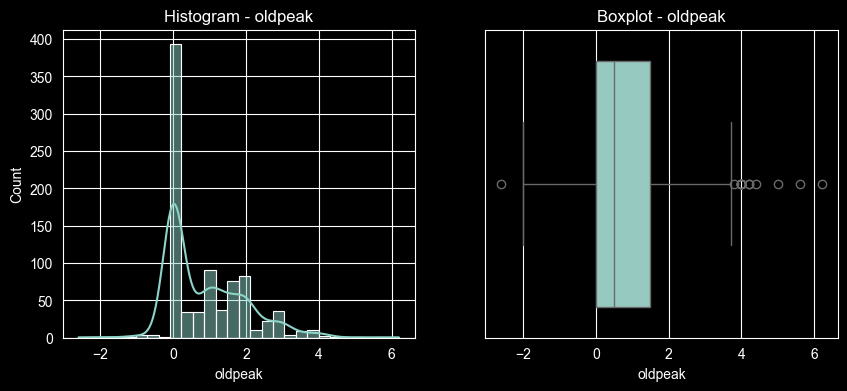

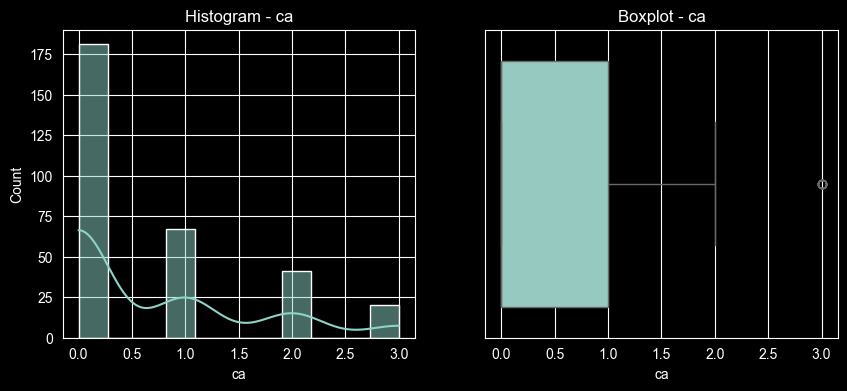

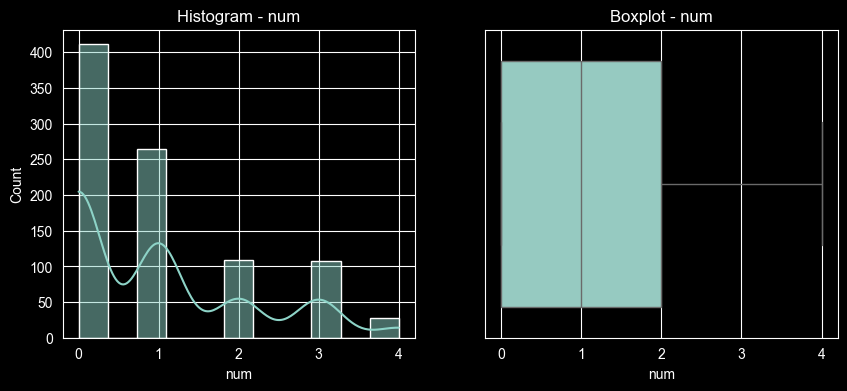

In [11]:
###1. Vẽ biểu đồ cho cột số (numerical)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram - {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')

    plt.show()

In [12]:
###2. Xem phân phối cột danh mục (categorical)
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


sex
sex
Male      726
Female    194
Name: count, dtype: int64

dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

fbs
fbs
False    692
True     138
Name: count, dtype: int64

restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

exang
exang
False    528
True     337
Name: count, dtype: int64

slope
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

thal
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


C:\Users\ngoot\AppData\Local\Temp\ipykernel_18516\2434366558.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


In [13]:
###vì cp, thal, slope, restecg thường là categorical dạng số nên ta ép kiễu
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','num']

- Dựa trên histogram và boxplot, một số cột số như chol và oldpeak xuất hiện outlier rõ ràng, có thể làm lệch giá trị trung bình.
- Các cột như age, thalach có phân phối tương đối ổn định, ít bị ảnh hưởng bởi outlier.
- Các cột categorical như cp, thal, slope không có thứ tự tự nhiên và có nhiều nhóm giá trị khác nhau.
- Các cột nhị phân như sex, fbs, exang đã được mã hóa dạng 0/1 nên không cần xử lý thêm.

Bảng Quyết Định

| Cột      | Strategy                     | Lý do                                              |
| -------- | ---------------------------- | -------------------------------------------------- |
| age      | Giữ nguyên, scale            | Không có outlier rõ ràng, phân phối khá đều        |
| trestbps | Dùng median nếu có missing   | Boxplot có một vài outlier → mean dễ bị lệch       |
| chol     | Dùng median                  | Boxplot cho thấy outlier lớn (~500+) kéo lệch mean |
| thalach  | Scale                        | Phân phối ổn, không outlier nghiêm trọng           |
| oldpeak  | Median + scale               | Có lệch phải và outlier                            |
| ca       | Có thể giữ nguyên hoặc scale | Giá trị nhỏ (0–3), có thứ tự                       |
| sex      | Giữ nguyên (0/1)             | Đã là nhị phân                                     |
| fbs      | Giữ nguyên (0/1)             | Không cần encode                                   |
| exang    | Giữ nguyên (0/1)             | Không cần encode                                   |
| cp       | One-hot encoding             | Là categorical không có thứ tự                     |
| restecg  | One-hot encoding             | Không có thứ tự                                    |
| slope    | One-hot encoding             | Không có thứ tự                                    |
| thal     | One-hot encoding             | Nhiều nhóm khác nhau                               |
| target   | Không xử lý                  | Biến mục tiêu                                      |

- Các cột số có outlier hoặc phân phối lệch được xử lý bằng median để giảm ảnh hưởng của giá trị cực đoan.
- Các cột số còn lại được scale để đưa về cùng thang đo, giúp mô hình học tốt hơn.
- Các cột categorical không có thứ tự được chuyển sang one-hot encoding để tránh mô hình hiểu sai quan hệ giữa các giá trị.
- Các cột nhị phân được giữ nguyên vì đã ở dạng phù hợp.

3.Demo kiểm tra strategy

In [14]:
###1.Tạo X_train
# fix tên cột nếu có khoảng trắng
df.columns = df.columns.str.strip()

# target đúng
target_col = 'num'

# tách X, y
X = df.drop(target_col, axis=1)
y = df[target_col]

# bỏ cột không cần
X = X.drop(['id', 'dataset'], axis=1)

# chia train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(" Đã tạo X_train")

 Đã tạo X_train


In [15]:
###2.Demo subset
subset = X_train.head(10).copy()

print("=== TRƯỚC ===")
print(subset)

print("\nNaN ban đầu:")
print(subset.isnull().sum())

=== TRƯỚC ===
     age     sex               cp  trestbps   chol    fbs           restecg  \
880   62    Male     asymptomatic       NaN  170.0  False  st-t abnormality   
457   54    Male      non-anginal     150.0    NaN  False            normal   
797   51    Male      non-anginal       NaN  339.0  False            normal   
25    50  Female      non-anginal     120.0  219.0  False            normal   
84    52    Male  atypical angina     120.0  325.0  False            normal   
10    57    Male     asymptomatic     140.0  192.0  False            normal   
346   40    Male      non-anginal     130.0  281.0  False            normal   
548   54    Male     asymptomatic     200.0  198.0  False            normal   
636   52    Male     asymptomatic      95.0    0.0    NaN            normal   
594   56    Male     asymptomatic     155.0  342.0   True            normal   

     thalch  exang  oldpeak      slope   ca          thal  
880   120.0   True      3.0        NaN  NaN           Na

In [16]:
###3.Áp dụng SimpleImputer
# chia nhóm cột
mean_cols = ['age', 'trestbps', 'thalch']
median_cols = ['chol', 'oldpeak']
mode_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']

# mean
imputer_mean = SimpleImputer(strategy='mean')
subset[mean_cols] = imputer_mean.fit_transform(subset[mean_cols])

# median
imputer_median = SimpleImputer(strategy='median')
subset[median_cols] = imputer_median.fit_transform(subset[median_cols])

# mode
imputer_mode = SimpleImputer(strategy='most_frequent')
subset[mode_cols] = imputer_mode.fit_transform(subset[mode_cols])

In [17]:
###4.Kiểm tra sau khi xử lý
print("\n=== SAU ===")
print(subset)

print("\nNaN còn lại:")
print(subset.isnull().sum())


=== SAU ===
      age     sex               cp  trestbps   chol    fbs           restecg  \
880  62.0    Male     asymptomatic    138.75  170.0  False  st-t abnormality   
457  54.0    Male      non-anginal    150.00  219.0  False            normal   
797  51.0    Male      non-anginal    138.75  339.0  False            normal   
25   50.0  Female      non-anginal    120.00  219.0  False            normal   
84   52.0    Male  atypical angina    120.00  325.0  False            normal   
10   57.0    Male     asymptomatic    140.00  192.0  False            normal   
346  40.0    Male      non-anginal    130.00  281.0  False            normal   
548  54.0    Male     asymptomatic    200.00  198.0  False            normal   
636  52.0    Male     asymptomatic     95.00    0.0  False            normal   
594  56.0    Male     asymptomatic    155.00  342.0   True            normal   

         thalch  exang  oldpeak      slope   ca          thal  
880  120.000000   True      3.0       flat

In [18]:
###5.Xem giá trị điền
print("\nGiá trị đã dùng:")

print("Mean:", dict(zip(mean_cols, imputer_mean.statistics_)))
print("Median:", dict(zip(median_cols, imputer_median.statistics_)))
print("Mode:", dict(zip(mode_cols, imputer_mode.statistics_)))


Giá trị đã dùng:
Mean: {'age': np.float64(52.8), 'trestbps': np.float64(138.75), 'thalch': np.float64(140.11111111111111)}
Median: {'chol': np.float64(219.0), 'oldpeak': np.float64(1.0)}
Mode: {'sex': 'Male', 'cp': 'asymptomatic', 'fbs': False, 'restecg': 'normal', 'exang': False, 'slope': 'flat', 'thal': 'normal', 'ca': 0.0}


4.Demo OneHotEncoder

In [19]:
###1.Lấy subset + cột cp
subset_cp = X_train[['cp']].head(10).copy()

print("=== TRƯỚC OHE ===")
print(subset_cp)

=== TRƯỚC OHE ===
                  cp
880     asymptomatic
457      non-anginal
797      non-anginal
25       non-anginal
84   atypical angina
10      asymptomatic
346      non-anginal
548     asymptomatic
636     asymptomatic
594     asymptomatic


In [20]:
###2. Áp dụng OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

cp_encoded = ohe.fit_transform(subset_cp)

# lấy tên cột mới
cp_columns = ohe.get_feature_names_out(['cp'])

# chuyển về DataFrame cho dễ nhìn
import pandas as pd
cp_df = pd.DataFrame(cp_encoded, columns=cp_columns)

print("\n=== SAU OHE ===")
print(cp_df)


=== SAU OHE ===
   cp_asymptomatic  cp_atypical angina  cp_non-anginal
0              1.0                 0.0             0.0
1              0.0                 0.0             1.0
2              0.0                 0.0             1.0
3              0.0                 0.0             1.0
4              0.0                 1.0             0.0
5              1.0                 0.0             0.0
6              0.0                 0.0             1.0
7              1.0                 0.0             0.0
8              1.0                 0.0             0.0
9              1.0                 0.0             0.0


In [21]:
result = pd.concat([subset_cp.reset_index(drop=True), cp_df], axis=1)
print("\n=== SO SÁNH ===")
print(result)


=== SO SÁNH ===
                cp  cp_asymptomatic  cp_atypical angina  cp_non-anginal
0     asymptomatic              1.0                 0.0             0.0
1      non-anginal              0.0                 0.0             1.0
2      non-anginal              0.0                 0.0             1.0
3      non-anginal              0.0                 0.0             1.0
4  atypical angina              0.0                 1.0             0.0
5     asymptomatic              1.0                 0.0             0.0
6      non-anginal              0.0                 0.0             1.0
7     asymptomatic              1.0                 0.0             0.0
8     asymptomatic              1.0                 0.0             0.0
9     asymptomatic              1.0                 0.0             0.0


Kết quả sau khi áp dụng OneHotEncoder cho cột cp. Sau khi áp dụng OneHotEncoder cho cột cp, dữ liệu được chuyển từ dạng categorical (chuỗi) sang dạng số với nhiều cột nhị phân.

Cụ thể, cột cp có 4 giá trị khác nhau nên sau khi encode tạo ra 4 cột mới:
- cp_typical angina
- cp_asymptomatic
- cp_non-anginal
- cp_atypical angina

Mỗi dòng dữ liệu chỉ có một giá trị bằng 1, các cột còn lại bằng 0

In [22]:
###3.Kiểm tra logic OHE
print("\nTổng mỗi hàng (phải = 1):")
print(cp_df.sum(axis=1))


Tổng mỗi hàng (phải = 1):
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
dtype: float64


Khi kiểm tra tổng các giá trị trên mỗi hàng sau khi encode, kết quả luôn bằng 1.
Điều này xác nhận rằng:
- Mỗi bệnh nhân chỉ thuộc một loại đau ngực duy nhất
- Không có trường hợp dữ liệu bị encode sai (ví dụ nhiều hơn 1 giá trị bằng 1)

Số lượng cột sau khi áp dụng OneHotEncoder

Các cột categorical trong dataset gồm:
- sex: 2 giá trị → 2 cột
- cp: 4 giá trị → 4 cột
- fbs: 2 giá trị → 2 cột
- restecg: 3 giá trị → 3 cột
- exang: 2 giá trị → 2 cột
- slope: 3 giá trị → 3 cột
- thal: 3 giá trị → 3 cột

 Tổng số cột sau OneHotEncoder: 19 cột

Tổng số cột input sau khi encode
- Số cột ban đầu: 13 cột
- Số cột categorical được thay thế: 7 cột
- Số cột mới sau encode: 19 cột

Tổng số cột sau xử lý: 13 - 7 + 19 = 25 cột

Kết luận : OneHotEncoder là phương pháp phù hợp cho các cột nominal (không có thứ tự). Giúp model học đúng bản chất dữ liệu . Tránh sai lệch do hiểu nhầm thứ tự giữa các giá trị . Tuy làm tăng số chiều dữ liệu, nhưng đảm bảo tính chính xác và hiệu quả của mô hình

### VIII.Feature Engineering

#### 1.Tạo các Feature mới

Giải thích lí do tạo ra các feature này:

**Feature 1: heart_rate_ratio — Tỷ lệ nhịp tim đạt được**

Công thức Karvonen trong y học: nhịp tim tối đa lý thuyết của một người = 220 trừ tuổi. Đây là ngưỡng tối đa tim có thể đập được. Khi bác sĩ làm stress test (kiểm tra gắng sức), họ theo dõi bệnh nhân có đạt được bao nhiêu % ngưỡng tối đa này. Ý nghĩa lâm sàng: người đạt < 85% ngưỡng tối đa trong stress test có nguy cơ bệnh tim mạch cao hơn đáng kể. Bác sĩ gọi đây là 'chronotropic incompetence'. Feature heart_rate_ratio chính là cách đo tỷ lệ này.

**Cách tính:** Lấy giá trị thalach chia cho (220 trừ age). Kết quả là số thực từ 0 đến ~1.1.

**Tại sao tốt hơn dùng riêng thalach?**
 Bởi vì thalach=150 có ý nghĩa khác nhau hoàn toàn tùy theo tuổi. Người 30 tuổi có thalach=150 đang đạt 75% khả năng tối đa (150/200). Người 70 tuổi có thalach=150 đang đạt 100% (150/150) — xuất sắc. Feature mới nắm bắt được sự phụ thuộc phi tuyến này.

**Feature 2: age_risk_group — Nhóm nguy cơ theo tuổi**

Nguy cơ bệnh tim mạch không tăng tuyến tính (đều đặn) theo tuổi. Nghiên cứu lâm sàng cho thấy nguy cơ tăng vọt tại các ngưỡng nhất định: sau 40 tuổi, sau 50 tuổi, và sau 60 tuổi. Đây là hiện tượng 'threshold effect' — ngưỡng nguy hiểm. Nếu dùng age trực tiếp, model tuyến tính (như Logistic Regression) khó nhận ra được các ngưỡng phi tuyến này. Nhóm hóa giúp 'biến đổi' mối quan hệ phi tuyến thành dạng mà model có thể học được

**Cách tính:** Phân nhóm age thành 4 nhóm: 0–40 (nhóm 0), 40–50 (nhóm 1), 50–60 (nhóm 2), 60+ (nhóm 3). Kết quả là số nguyên 0–3 thể hiện mức nguy cơ tăng dần.



In [23]:
def feature_engineering(df):
    """
    Thực hiện tạo các đặc trưng mới dựa trên kiến thức y sinh.
    """
    # Bước 1: Luôn copy dữ liệu gốc
    df_fe = df.copy()

    # Hàm nhỏ 1: Tính toán heart_rate_ratio
    def create_heart_rate_ratio(data):
        # Công thức Karvonen: thalch / (220 - age)
        return data['thalch'] / (220 - data['age'])

    # Hàm nhỏ 2: Phân nhóm tuổi nguy cơ
    def create_age_risk_group(data):
        bins = [0, 40, 50, 60, np.inf]
        labels = [0, 1, 2, 3]
        # Ép kiểu về int để Pipeline không lỗi
        return pd.cut(data['age'], bins=bins, labels=labels).astype(int)

    # Bước 2: Gọi các hàm nhỏ để gán giá trị vào DataFrame
    df_fe['heart_rate_ratio'] = create_heart_rate_ratio(df_fe)
    df_fe['age_risk_group'] = create_age_risk_group(df_fe)

    return df_fe

In [24]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats


#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv
    Args:
        dataset_path (str): đường dẫn file csv
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None

    try:
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None


#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


In [25]:
#Dùng hàm astype để convert tất cả dữ liệu trong cột từ bool thành int
df['target'] = (df['num'] > 0).astype(int)

#Hiển thị dữ liệu đã thêm target
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [26]:

# Tự tạo X_train tạm thời để test code
X = df.drop(columns=['target'])  # Tách cột target ra
X_train = X.copy()  # Tạm thời coi toàn bộ data là X_train để test hàm

X_train_fe = feature_engineering(X_train)
# Tiến hành in kiểm tra
print("--- THỐNG KÊ KIỂM TRA FEATURE MỚI ---")
display(X_train_fe[['heart_rate_ratio', 'age_risk_group']].describe())

--- THỐNG KÊ KIỂM TRA FEATURE MỚI ---


,heart_rate_ratio,age_risk_group
count,865.000000,920.000000
mean,0.823760,1.794565
std,0.145711,0.920196
min,0.355030,0.000000
25%,0.718563,1.000000
50%,0.833333,2.000000
75%,0.938547,2.000000
max,1.174699,3.000000


#### 2. Visualize (Trực quan hóa)

---VẼ BIỂU ĐỒ 1 (BOXPLOT) ---


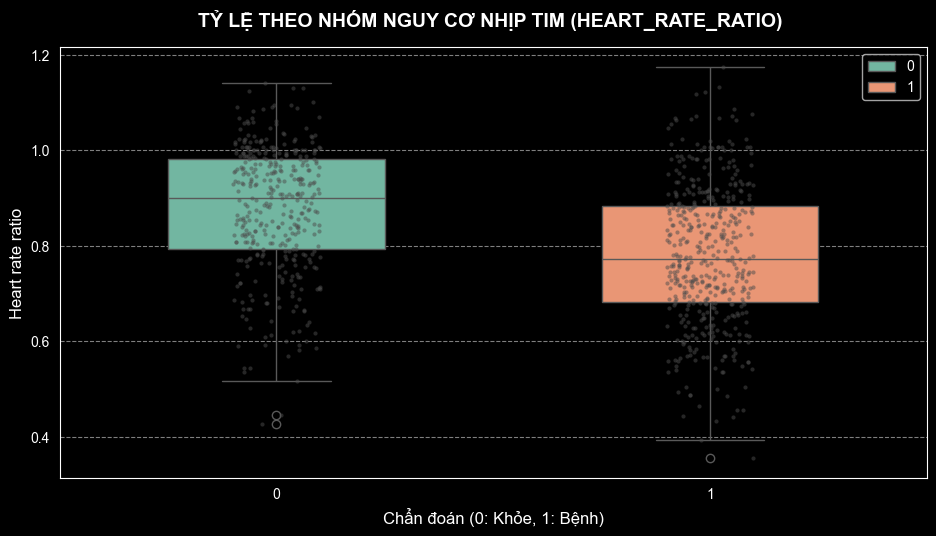

--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---


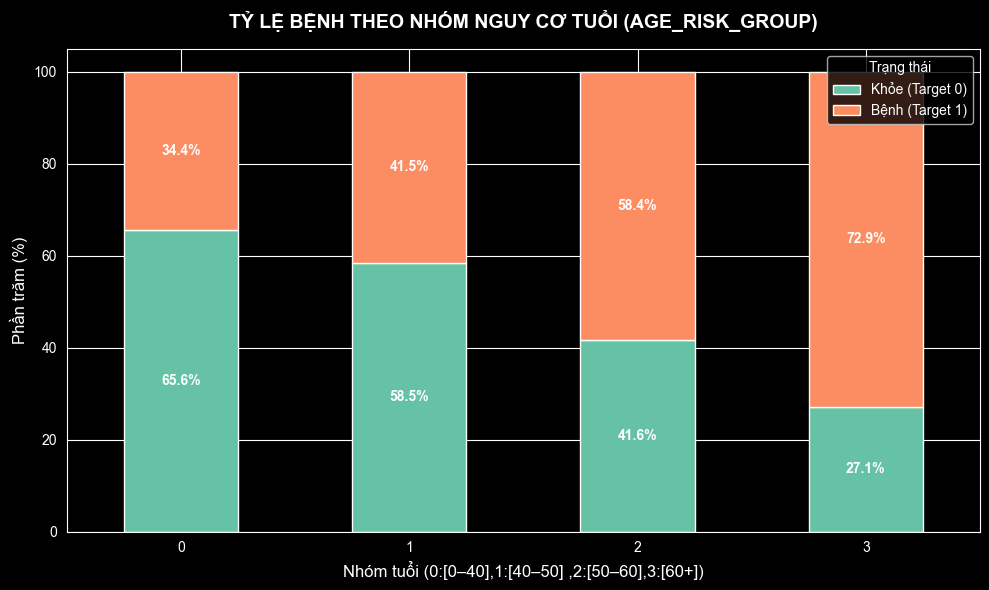

In [27]:
def plot_boxplot_heart_rate(df, configs):
    """
    Vẽ biểu đồ Boxplot kết hợp Stripplot để so sánh biến số theo Target.

    Args:
        df (pd.DataFrame): Bảng dữ liệu đã có feature mới.
        configs (list of tuples): Danh sách (tên_cột_số, tên_palette).
    """
    # Tạo khung hình dựa trên số lượng cấu hình truyền vào
    fig, axes = plt.subplots(nrows=len(configs), ncols=1, figsize=(10, 6 * len(configs)))

    # Ép về list nếu chỉ có 1 biểu đồ để vòng lặp for không bị lỗi
    if len(configs) == 1:
        axes = [axes]

    for i, (col, pal) in enumerate(configs):
        ax = axes[i]

        # 1. Vẽ Boxplot làm nền (thể hiện tứ phân vị và trung vị)
        sns.boxplot(data=df, x='target', y=col, palette=pal, hue='target', ax=ax, width=0.5)

        # 2. Vẽ thêm Stripplot (hiển thị từng chấm dữ liệu thực tế)
        sns.stripplot(data=df, x='target', y=col, color=".3", size=3, alpha=0.5, ax=ax)

        # 3. Tinh chỉnh
        ax.set_title(f'TỶ LỆ THEO NHÓM NGUY CƠ NHỊP TIM ({col.upper()}) ', pad=15, fontsize=14, fontweight='bold')
        ax.set_xlabel('Chẩn đoán (0: Khỏe, 1: Bệnh)', fontsize=12)
        ax.set_ylabel(col.replace('_', ' ').capitalize(), fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()


def plot_stacked_age_risk(df, col):
    """
    Vẽ biểu đồ Stacked Bar Chart cho age_risk_group .
    """
    # 1. Tính toán tỷ lệ % (Màu xanh = khỏe, Màu cam/đỏ = bệnh)
    data_pct = pd.crosstab(df[col], df['target'], normalize='index') * 100

    # 2. Vẽ biểu đồ cột chồng
    ax = data_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])

    # 3. Tinh chỉnh
    plt.title(f'TỶ LỆ BỆNH THEO NHÓM NGUY CƠ TUỔI ({col.upper()})', pad=15, fontsize=14, fontweight='bold')
    plt.xlabel('Nhóm tuổi (0:[0–40],1:[40–50] ,2:[50–60],3:[60+])', fontsize=12)
    plt.ylabel('Phần trăm (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Khỏe (Target 0)', 'Bệnh (Target 1)'], loc='upper right', title='Trạng thái')

    # Gắn nhãn số % lên cột
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center', color='white',
                    fontweight='bold')

    plt.tight_layout()
    plt.show()


####################
df_fe = feature_engineering(df)

# BIỂU ĐỒ 1: Boxplot cho biến số (heart_rate_ratio)
print("---VẼ BIỂU ĐỒ 1 (BOXPLOT) ---")
my_heart_rate_configs = [('heart_rate_ratio', 'Set2')]
plot_boxplot_heart_rate(df=df_fe, configs=my_heart_rate_configs)

# BIỂU ĐỒ 2: Stacked Bar cho biến phân loại (age_risk_group)
print("--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---")
plot_stacked_age_risk(df=df_fe, col='age_risk_group')


**Nhận xét:**

**Biểu đồ 1:**

**Xu hướng chính:** Có sự khác biệt rõ rệt về phân phối chỉ số giữa hai nhóm. Nhóm khỏe mạnh (Target 0 - Màu xanh) có hộp nằm ở vị trí cao hơn hẳn so với nhóm bệnh lý (Target 1 - Màu cam).

**Giá trị trung vị:** Nhóm khỏe mạnh có trung vị nhịp tim đạt được xấp xỉ 0.9 (90% ngưỡng tối đa), trong khi nhóm bệnh lý chỉ đạt khoảng 0.78.

**Ý nghĩa y sinh:** Kết quả này chứng minh rằng bệnh nhân tim mạch thường gặp tình trạng "suy giảm khả năng đáp ứng nhịp tim" khi gắng sức.

**Kết luận:** Đặc trưng này giúp mô hình phân tách tốt hai nhóm đối tượng vì dải giá trị của chúng ít bị chồng lấn đáng kể ở phần lõi (hộp).

**Biểu đồ 2:**

**Xu hướng chính:** Tỷ lệ phần trăm bệnh nhân (màu cam) có xu hướng tăng dần đều theo các nhóm tuổi từ trẻ đến già.

**Con số biết nói:** Ở nhóm tuổi trẻ nhất (nhóm 0), tỷ lệ mắc bệnh chỉ chiếm 34.4%. Tỷ lệ này tăng vọt lên 72.9% ở nhóm tuổi cao nhất (nhóm 3).

**Ý nghĩa y sinh:** Đặc trưng này phản ánh chính xác quy luật sinh học là nguy cơ mắc bệnh tim mạch tỉ lệ thuận với độ tuổi, đặc biệt là sau ngưỡng 50-60 tuổi.

**Kết luận:** Việc chia nhóm tuổi (age_risk_group) là một bước xử lý dữ liệu thông minh, giúp mô hình nắm bắt được các "điểm gãy" nguy cơ theo từng giai đoạn cuộc đời thay vì chỉ nhìn con số tuổi đơn thuần.

#### 4. Đánh giá định lượng

In [29]:
# 1. TẠO DF_CLEAN (Làm sạch toàn bộ dữ liệu gốc)
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip() # Xóa khoảng trắng tên cột

# Định nghĩa lại các nhóm cột
mean_cols = ['age', 'trestbps', 'thalch']
median_cols = ['chol', 'oldpeak']
mode_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']

# Áp dụng Imputer cho TOÀN BỘ bảng
from sklearn.impute import SimpleImputer
imputer_mean = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

df_clean[mean_cols] = imputer_mean.fit_transform(df_clean[mean_cols])
df_clean[median_cols] = imputer_median.fit_transform(df_clean[median_cols])
df_clean[mode_cols] = imputer_mode.fit_transform(df_clean[mode_cols])

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



def evaluate_model_improvement(df_original, df_fe):
    # 1. Danh sách cột gốc (Sửa lại thalach cho chuẩn)
    original_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                     'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

    # 2. Xử lý Target: Chuyển num (>0 thành 1) để làm bài toán Nhị phân
    # Chúng ta tạo bản copy để không làm hỏng dữ liệu gốc bên ngoài
    y_base = (df_original['num'] > 0).astype(int)
    y_fe = (df_fe['num'] > 0).astype(int)

    # 3. Chuẩn bị X (Lọc lấy cột và xử lý One-Hot)
    X_original = pd.get_dummies(df_original[original_cols], drop_first=True)
    X_fe = pd.get_dummies(df_fe[original_cols + ['heart_rate_ratio', 'age_risk_group']], drop_first=True)

    def get_score(X_data, y_data):
        model = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(max_iter=1000))
        ])
        # Chạy 5-fold cross validation
        return cross_val_score(model, X_data, y_data, cv=5, scoring='f1').mean()

    # 4. Tính toán
    f1_base = get_score(X_original, y_base)
    f1_new = get_score(X_fe, y_fe)

    print(f"\n--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---")
    print(f"F1 Baseline (Gốc): {f1_base:.7f}")
    print(f"F1 After FE (Mới): {f1_new:.7f}")

    improvement = (f1_new - f1_base) * 100
    print(f"Cải thiện: {improvement:.5f}%")

# Chạy lệnh thực thi
df_fe = feature_engineering(df_clean)
evaluate_model_improvement(df_clean, df_fe)


--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---
F1 Baseline (Gốc): 0.8033786
F1 After FE (Mới): 0.8034427
Cải thiện: 0.00640%
